In [1]:
!pip install -q shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import shap
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42


In [2]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [3]:
import os

dataset_path = "/kaggle/input/datasets"

print(os.listdir(dataset_path))

['jannatulferdaues']


In [4]:
import os

dataset_path = "/kaggle/input/datasets/jannatulferdaues"

print(os.listdir(dataset_path))

['ghdi-student-dataset']


In [5]:
import os

dataset_path = "/kaggle/input/datasets/jannatulferdaues/ghdi-student-dataset"

print(os.listdir(dataset_path))

['student_dataset.xlsx']


In [6]:
DATA_PATH = "/kaggle/input/datasets/jannatulferdaues/ghdi-student-dataset/student_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

# Drop the stray "Unnamed: 0" index column that Excel exports sometimes carry
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("Shape:", df.shape)
df.head()

Shape: (55000, 11)


,Country,University,Country_HDI,Country_Life_Expectancy,Education_Level,Field_of_Study,Language_Proficiency,Health_Quality_Score_1to5,Stress_Level_1to5,Monthly_Earnings_Savings_USD,Readiness_Score_0to100
0,Afghanistan,Afghan University,0.498,57.950001,Master's,Natural Sciences,Native/Fluent,2,2,1316.37,61
1,Afghanistan,Afghan University,0.498,57.950001,Undergraduate,Education,Native/Fluent,2,4,1892.79,70
2,Afghanistan,Afghan University,0.498,57.950001,Undergraduate,Social Sciences & Psychology,Native/Fluent,2,4,2030.31,69
3,Afghanistan,Afghan University,0.498,57.950001,Undergraduate,Engineering & Technology,Native/Fluent,3,2,1646.31,64
4,Afghanistan,Afghan University,0.498,57.950001,Master's,"Arts, Humanities & Design",Beginner (A1-A2),2,3,1299.43,52


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       55000 non-null  object 
 1   University                    55000 non-null  object 
 2   Country_HDI                   55000 non-null  float64
 3   Country_Life_Expectancy       55000 non-null  float64
 4   Education_Level               55000 non-null  object 
 5   Field_of_Study                55000 non-null  object 
 6   Language_Proficiency          55000 non-null  object 
 7   Health_Quality_Score_1to5     55000 non-null  int64  
 8   Stress_Level_1to5             55000 non-null  int64  
 9   Monthly_Earnings_Savings_USD  55000 non-null  float64
 10  Readiness_Score_0to100        55000 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 4.6+ MB


In [8]:
df.describe()

,Country_HDI,Country_Life_Expectancy,Health_Quality_Score_1to5,Stress_Level_1to5,Monthly_Earnings_Savings_USD,Readiness_Score_0to100
count,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000
mean,0.715645,72.803022,3.559945,2.972873,1873.841880,65.492236
std,0.155013,7.395078,1.138753,1.031685,606.134564,10.113286
min,0.354000,50.160000,1.000000,1.000000,50.000000,28.000000
25%,0.591000,67.339996,3.000000,2.000000,1465.117500,58.000000
50%,0.747000,74.580002,4.000000,3.000000,1885.790000,66.000000
75%,0.838000,78.260002,4.000000,4.000000,2289.947500,73.000000
max,0.953000,83.940002,5.000000,5.000000,4422.740000,97.000000


#  Check for missing values and duplicates

In [9]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Country                         0
University                      0
Country_HDI                     0
Country_Life_Expectancy         0
Education_Level                 0
Field_of_Study                  0
Language_Proficiency            0
Health_Quality_Score_1to5       0
Stress_Level_1to5               0
Monthly_Earnings_Savings_USD    0
Readiness_Score_0to100          0
dtype: int64

Duplicate rows: 0


#  Visualization

## Target distribution


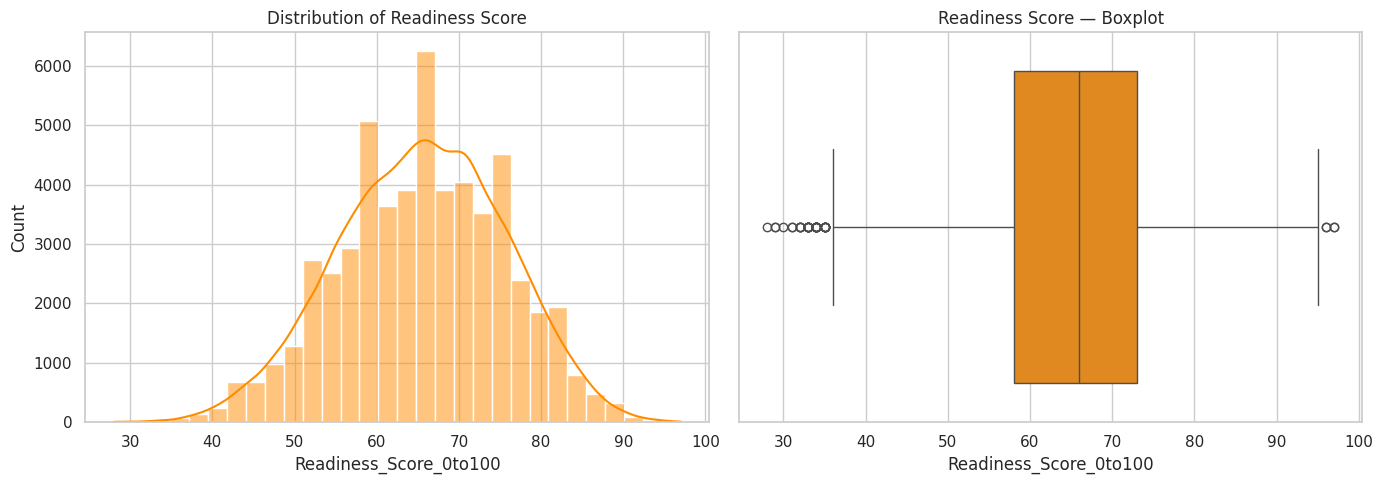

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Readiness_Score_0to100"], kde=True, bins=30, ax=ax[0], color="darkorange")
ax[0].set_title("Distribution of Readiness Score")

sns.boxplot(x=df["Readiness_Score_0to100"], ax=ax[1], color="darkorange")
ax[1].set_title("Readiness Score — Boxplot")
plt.tight_layout()
plt.show()

##  Correlation heatmap (numeric features)

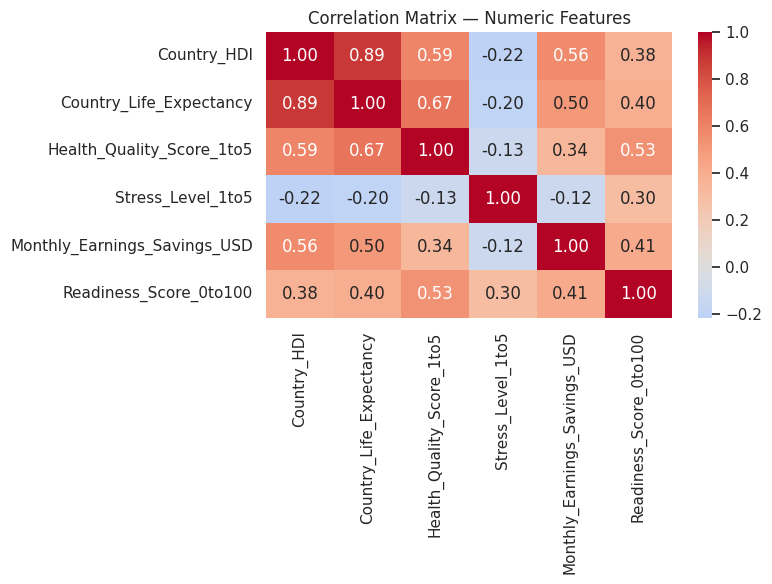

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()
